In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

Compare raw data across animals

In [2]:
def _exploreISA(session,regs=None):
    # firing rates per electrode
    R = rg.data.Regions(session)
    fr = R.firingRate(e_groups=R.electrodes(regs),when='sleep.*#0',window=0.05,step=5,smooth=70,norm=True)
    return fr, R.basename

In [ ]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][57]
fr, base = _exploreISA(session)

In [ ]:
# 1. NR across electrodes
fr, base = fma.data.runBatch(batch_file,_exploreISA,kwargs={'regs': 'nr'},ignore_args=True,parallel=True)

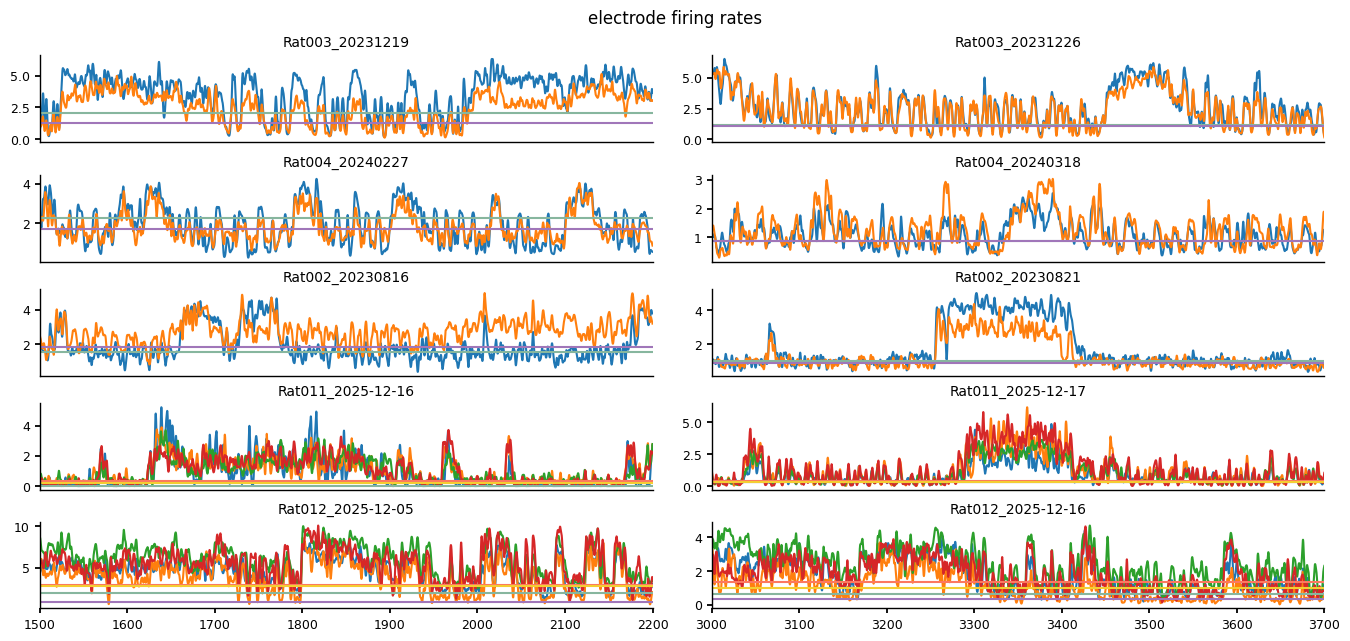

In [9]:
# IS Rat002_20230821 in TH??
start = np.array([2200,2300,2000,2000,2700,4000,2000,2000,1500,3000])
stop = start + 700
threshold = 20
sessions = [5,10,15,29,35,40,60,61,62,68]
fig, ax = fma.plotting.makeFigure('electrode firing rates',[len(sessions)//2,2],size=[34,3.2*len(sessions)//2])
for i, s in enumerate(sessions):
    a_idx = np.unravel_index(i,ax.shape)
    fma.plotting.plotXY(fr[s],start[i],stop[i],ax=ax[a_idx])
    percent = np.percentile(fr[s][:,1:],threshold,axis=0)
    [ax[a_idx].axhline(p,color=isru.paperColors(j)) for j, p in enumerate(percent)]
    ax[a_idx].set_title(base[s],fontsize=10), ax[a_idx].set_xlim([start[i],stop[i]])
fma.plotting.setProp(ax[:-1],xticks=[]);

NR exhibits unique infra-slow avalanches

In [16]:
# parameters
session = fma.data.readBatchFile(batch_file)[0][57]
print(f'session: {session}')
# load data
R = rg.data.Regions(session)
regs = R.ids
when = 'sleep.*#0'
threshold = 20

session: /mnt/hubel-data-149/Rat012/Rat012_2025-12-17/Rat012_2025-12-17.xml


In [17]:
S, T, s_t, fr = R.avalanches(when=when,window=0.05,step=5,smooth=70,thresh=threshold,return_fr=True)
durations = {str(r): np.diff(T[r]).ravel() for r in T}
silences = {str(r): np.stack(([T[r][:-1,1],T[r][1:,0]]),axis=1) for r in T}
sil_durations = {str(r): np.diff(silences[r]).ravel() for r in silences}

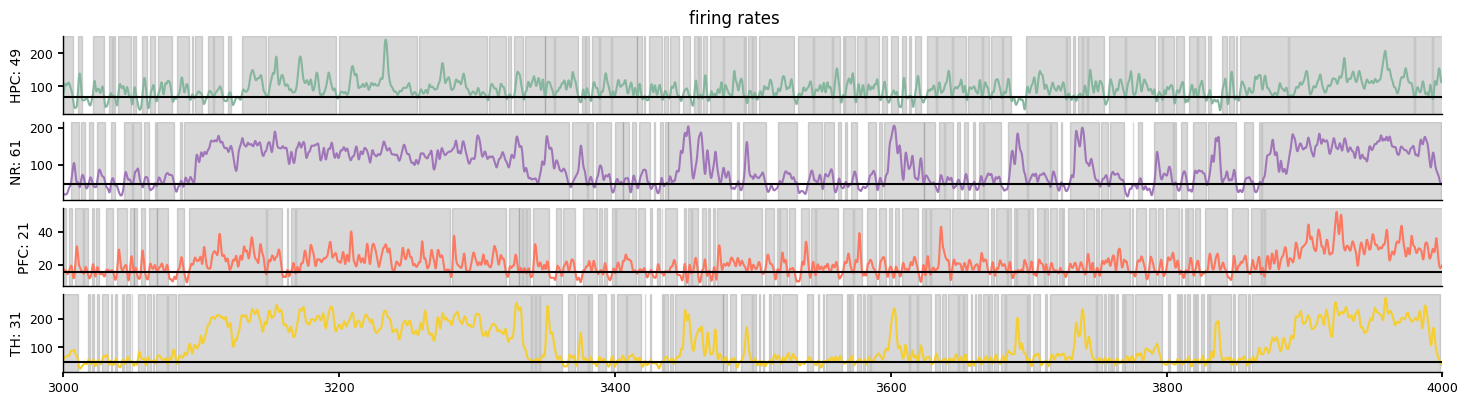

In [18]:
fig, ax = fma.plotting.makeFigure('firing rates',[len(regs),1],size=[37,10])
start = 3000
stop = start + 1000
t_ind = (start <= fr[:,0]) & (fr[:,0] <= stop)
for i, r in enumerate(regs):
    ax[i].plot(fr[t_ind,0],fr[t_ind,i+1],color=isru.paperColors(r))
    percent = np.percentile(fr[:,i+1],[threshold])
    [ax[i].axhline(p,color='k') for p in percent]
    fma.plotting.plotIntervals(T[r],ax=ax[i])
    ax[i].set_ylabel(f'{r.upper()}: {len(R.units(r))}')
fma.plotting.setProp(ax,xlim=[start,stop]), fma.plotting.setProp(ax[:-1],xticks=[]);

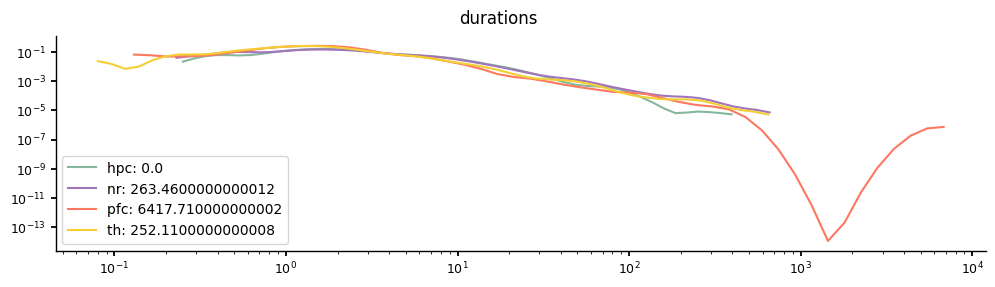

In [19]:
# higher max-avalanche duration, drop in tail separates two different states?
fig, ax = fma.plotting.makeFigure('durations',size=[25,7])
min_max_dur = np.min([durations[r].max() for r in durations])
delta_min_max = {r: durations[r].max() - min_max_dur for r in durations}
fma.plotting.plotPDF(tuple(durations.values()),bandwidth=0.2,log=True,color=isru.paperColors(range(len(regs))),label=[f'{r}: {delta_min_max[r]}' for r in regs],ax=ax[0])
ax[0].legend();

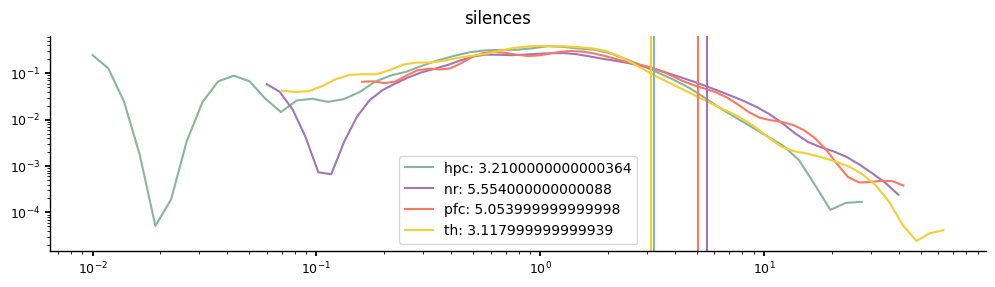

In [20]:
# bump in long silences
fig, ax = fma.plotting.makeFigure('silences',size=[25,7])
sil_perc = {r: np.percentile(sil_durations[r],80) for r in sil_durations}
fma.plotting.plotPDF(tuple(sil_durations.values()),bandwidth=0.2,log=True,color=isru.paperColors(range(len(regs))),label=[f'{r}: {sil_perc[r]}' for r in regs],ax=ax[0])
[ax[0].axvline(sil_perc[r],color=isru.paperColors(i)) for i, r in enumerate(sil_perc)]
ax[0].legend();

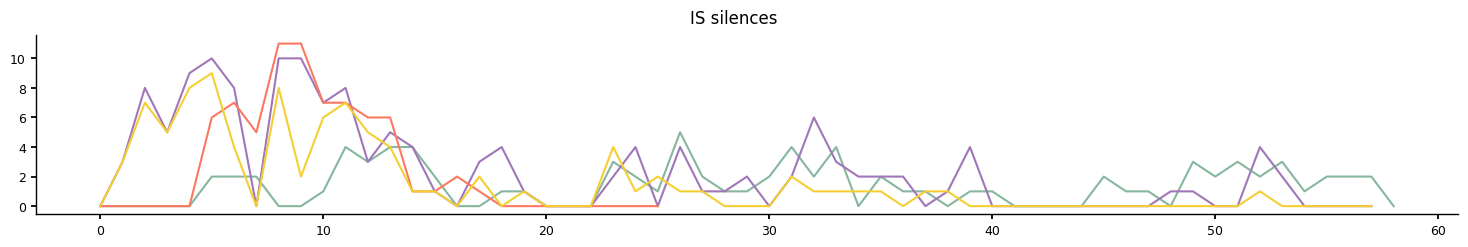

In [21]:
# infra-slow silences rate over time
fig, ax = fma.plotting.makeFigure('IS silences',size=[37,6])
for r in sil_durations:
    t_idx = (silences[r][:,0] // 200).astype(int)
    ax[0].plot(np.bincount(t_idx, sil_durations[r] > 5),color=isru.paperColors(r))

hpc 271.2430000000003
nr 113.07400000000057
pfc 57.363999999999834
th 231.55499999999958


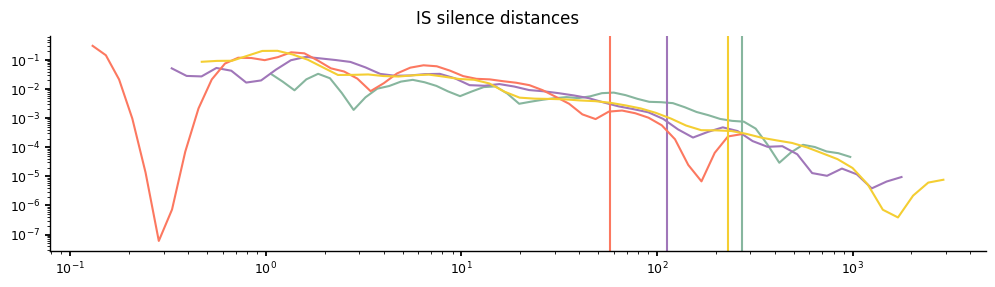

In [42]:
# time distance between big silences
fig, ax = fma.plotting.makeFigure('IS silence distances',size=[25,7])
for r in sil_durations:
    is_high = (sil_durations[r] > 5).ravel() # s
    high_distances = silences[r][is_high,0][1:] - silences[r][is_high,1][:-1]
    fma.plotting.plotPDF(high_distances,bandwidth=0.1,log=True,color=isru.paperColors(r),ax=ax[0])
    ax[0].axvline(np.percentile(high_distances,90),color=isru.paperColors(r))
    print(f'{r} {np.percentile(high_distances,90)}')

In [71]:
# number of consecutive infra slow silences + its average KILLED BY SHUFFLE
n_consec = {r: np.zeros(2) for r in sil_durations}
avrg_consec = {r: np.zeros(2) for r in sil_durations}
for r in sil_durations:
    is_high = (sil_durations[r] > 5).ravel() # s
    is_high = np.stack((is_high,is_high[np.random.permutation(len(is_high))]),axis=0)
    for i, ih in enumerate(is_high):
        keep = np.ones(len(ih),dtype=bool)
        keep[1:-1] = ih[1:-1] | ~ih[:-2] | ~ih[2:] # allow holes of 1 small silence
        ih = ih[keep]
        is_consecutive_high = ih[:-1] & ih[1:]
        groups, _, _ = fma.analysis.avalanchesFromProfile(is_consecutive_high.astype(float),0,1)
        n_consec[r][i] = np.sum(is_consecutive_high)
        avrg_consec[r][i] = groups.mean()
print(n_consec)
print(avrg_consec)

{'hpc': array([22.,  8.]), 'nr': array([53., 39.]), 'pfc': array([19., 17.])}
{'hpc': array([1.57142857, 1.        ]), 'nr': array([3.3125    , 2.16666667]), 'pfc': array([1.58333333, 1.41666667])}


In [ ]:
# autcorrelation in silence duration
aut_sil = {r: np.correlate(sil_durations[r][:-1].ravel(),sil_durations[r][1:].ravel()) for r in sil_durations}
print(aut_sil)

In [ ]:
# QUANTIFY THAT VARIANCE IN FR ON vs OFF is higher in nr!!!
fig, ax = fma.plotting.makeFigure('fr',size=[25,7])
fma.plotting.plotPDF(tuple(f for f in fr[:,1:].T),bandwidth=0.05,log=False,label=[f'{r}: {sil_perc[r]}' for r in regs],ax=ax[0])
[ax[0].axvline(np.percentile(fr[:,i+1],[threshold])) for i in range(len(regs))];

In [ ]:
# silence duration plotted
fig, ax = fma.plotting.makeFigure('silence dur',size=[25,7])
start = 0
stop = 100
[ax[0].plot(sil_durations[r][start:stop],color=isru.paperColors(i)) for i, r in enumerate(regs)];

run batch

In [5]:
def _ISAvalProperties(session,regs=None,threshold=np.arange(5,100,20),min_units=25,is_length=5):

    R = rg.data.Regions(session) # COULD GIVE regs
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)] # discard regions not found in R
    n_units = np.array([len(R.units(r)) for r in regs])
    regs = regs[n_units > min_units] # discard regions with too few units
    when = 'sleep.*#0'

    max_dur = np.full((len(regs),len(threshold)),np.nan) # (region, threshold)
    sil_perc = np.full((len(regs),len(threshold)),np.nan)
    n_consec = np.full((len(regs)+1,len(threshold)),np.nan)
    for j, t in enumerate(threshold):
        _, T, _ = R.avalanches(regs=regs,when=when,window=0.05,step=5,smooth=70,thresh=t)

        max_dur[:,j] = [np.diff(T[r]).max() for r in regs]

        silences = {r: np.stack(([T[r][:-1,1],T[r][1:,0]]),axis=1) for r in regs}
        sil_durations = {r: np.diff(silences[r]) for r in silences}
        sil_perc[:,j] = [np.percentile(sil_durations[r],80) for r in regs]

        is_high = {r: (sil_durations[r] > is_length).ravel() for r in regs} # 'is_length' s
        is_high['shuffle'] = is_high['nr'][np.random.permutation(len(is_high['nr']))] # add shuffle
        for r in is_high:
            keep = np.ones(len(is_high[r]),dtype=bool)
            keep[1:-1] = is_high[r][1:-1] | ~is_high[r][:-2] | ~is_high[r][2:] # allow holes of 1 small silence
            is_high[r] = is_high[r][keep]
        n_consec[:,j] = [np.sum(is_high[r][:-1] & is_high[r][1:]) for r in is_high]

    delta_min_max = max_dur - np.nanmin(max_dur,axis=0) # compute delta
    n_consec = n_consec / np.diff(R.eventIntervals(when)) # normalize to rate (Hz)

    max_dur = xr.DataArray(max_dur,dims=('region','threshold'),coords={'region': regs,'threshold': threshold, 'rat': int(R.rat)})
    # delta_min_max is an unfair comparison if regions change between sessions
    delta_min_max = xr.DataArray(delta_min_max,dims=('region','threshold'),coords={'region': regs,'threshold': threshold, 'rat': int(R.rat)})
    sil_perc = xr.DataArray(sil_perc,dims=('region','threshold'),coords={'region': regs,'threshold': threshold, 'rat': int(R.rat)})
    n_consec = xr.DataArray(n_consec,dims=('region','threshold'),coords={'region': np.append(regs,'shuffle'),'threshold': threshold, 'rat': int(R.rat)})

    return max_dur, delta_min_max, sil_perc, n_consec

In [6]:
threshold = np.arange(5,40,5)
regs = ['hpc','nr','pfc','th']
max_dur, delta_min_max, sil_perc, n_consec = fma.data.runBatch(batch_file,_ISAvalProperties,kwargs={'regs': regs, 'threshold': threshold},ignore_args=True,parallel=True)
# concatenate sessions
max_dur_cat = xr.concat([d for d in max_dur if d is not None],dim='rat',join='outer') # (session, region, threshold)
delta_cat = xr.concat([d for d in delta_min_max if d is not None],dim='rat',join='outer')
sil_cat = xr.concat([d for d in sil_perc if d is not None],dim='rat',join='outer')
consec_cat = xr.concat([d for d in n_consec if d is not None],dim='rat',join='outer')
# average per animal
max_dur_avg = max_dur_cat.groupby('rat').mean(dim='rat',skipna=True)
delta_avg = delta_cat.groupby('rat').mean(dim='rat',skipna=True)
sil_avg = sil_cat.groupby('rat').mean(dim='rat',skipna=True)
consec_avg = consec_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-06-19 12:36:01.146539 

Error in session /mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml (2)
operands could not be broadcast together with shapes (3,7) (2,1) 
Traceback:
Error in session /mnt/hubel-data-139/perceval/Rat003_20231226/Rat003_20231226.xml (10)
operands could not be broadcast together with shapes (4,7) (2,1) 
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
operands could not be broadcast together with shapes (3,7) (2,1) 
Traceback:
Error in session /mnt/hubel-data-149/Rat011/Rat011_2025-12-16/Rat011_2025-12-16.xml (48)
'nr'
Traceback:
Batch completed with 4 errors, 2026-06-19 12:39:20.058268


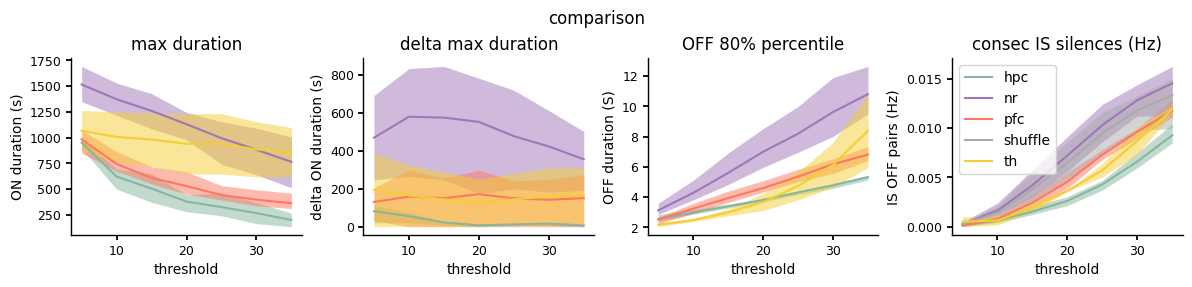

In [8]:
# proves 1. + 2. (BAD) NR has 2 states (very big avalanches) 3. NR has more IS silences 4. silences aggregate for NR (BAD)
fig, ax = fma.plotting.makeFigure('comparison',[1,4],size=[30,7])
for i, quantity in enumerate([max_dur_avg,delta_avg,sil_avg,consec_avg]):
    for r in quantity['region'].values:
        fma.plotting.semPlot(threshold,quantity.sel(region=r),color=isru.paperColors(r),label=r,ax=ax[i])
[ax[i].set_title(title) for i, title in enumerate(['max duration','delta max duration','OFF 80% percentile','consec IS silences (Hz)'])]
[ax[i].set_ylabel(l) for i, l in enumerate(['ON duration (s)','delta ON duration (s)','OFF duration (S)','IS OFF pairs (Hz)'])]
ax[-1].legend(), fma.plotting.setProp(ax,xlabel='threshold');

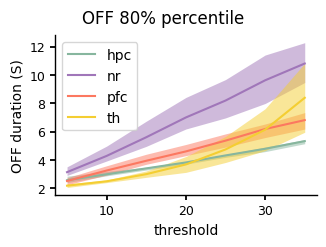

In [16]:
# plot OFF percentile
fig, ax = fma.plotting.makeFigure('OFF 80% percentile',size=[8,6])
for r in sil_avg['region'].values:
    fma.plotting.semPlot(threshold,sil_avg.sel(region=r),color=isru.paperColors(r),label=r,ax=ax[0])
ax[0].set_ylabel('OFF duration (S)'), ax[0].legend(), fma.plotting.setProp(ax,xlabel='threshold')
do_save and fma.plotting.saveFigure(fig,froot / 'off_percentile',['png','svg'])

CAN DO: compute variance around thresh in NR vs TH, latter much smaller?